# 05 — TTS Evaluation Analysis for Navigation Guidance

This notebook implements the evaluation  for offline text-to-speech (TTS) engines used in navigation commands.

## Evaluation goals
- Measure **Average Latency** and **P95 Latency**
- Measure **Real-Time Factor (RTF)** where `RTF = synthesis_time / audio_duration`
- Measure **Command Intelligibility** (first-hearing understanding rate)
- Compare **Multilingual Quality** (English, Hindi, Tamil; Gujarati optional)
- Record **Hardware Context** (CPU/GPU/RAM) for reproducibility

In [104]:
from __future__ import annotations

from dataclasses import dataclass, field
from datetime import datetime, timezone
from pathlib import Path
from typing import Any

import json
import os
import platform
import re
import shutil
import subprocess
import time
import wave

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
    import psutil
except Exception:
    psutil = None

try:
    from dotenv import load_dotenv
except Exception:
    load_dotenv = None


def find_project_root(start: Path) -> Path:
    """
    Find repo root even when notebook runs from `notebooks/`.
    We key off `pyproject.toml` + `app/` which exist in this repo.
    """
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").exists() and (candidate / "app").exists():
            return candidate
    return start


ROOT = find_project_root(Path.cwd())
DOC_PATH = ROOT / "docs" / "problem-statement.pdf"
TTS_LOG_DIR = ROOT / "logs" / "tts_eval"
AUDIO_DIR = TTS_LOG_DIR / "audio"

TTS_LOG_DIR.mkdir(parents=True, exist_ok=True)
AUDIO_DIR.mkdir(parents=True, exist_ok=True)

if load_dotenv is not None:
    load_dotenv(dotenv_path=ROOT / ".env", override=False)

print(f"Project root: {ROOT}")
print(f"PDF exists: {DOC_PATH.exists()} -> {DOC_PATH}")
print(f"TTS log dir: {TTS_LOG_DIR}")


Project root: c:\workspace\IITM\vision-nav-assist
PDF exists: True -> c:\workspace\IITM\vision-nav-assist\Docs\TTS_Evaluation (1).pdf
Output dir: c:\workspace\IITM\vision-nav-assist\logs\tts_eval


In [105]:
import matplotlib
from IPython import get_ipython
from IPython.display import display

def configure_matplotlib_show() -> str:
    backend = matplotlib.get_backend().lower()
    inline_backend = "module://matplotlib_inline.backend_inline"

    if "agg" in backend:
        try:
            plt.switch_backend(inline_backend)
            backend = matplotlib.get_backend().lower()
        except Exception:
            original_show = plt.show

            def safe_show(*args, **kwargs):
                figure = plt.gcf()
                display(figure)
                plt.close(figure)
                return None

            safe_show.__name__ = getattr(original_show, "__name__", "safe_show")
            plt.show = safe_show

    try:
        ip = get_ipython()
        if ip is not None:
            ip.run_line_magic("matplotlib", "inline")
            backend = matplotlib.get_backend().lower()
    except Exception:
        pass

    return backend

print(f"Matplotlib backend: {configure_matplotlib_show()}")

Matplotlib backend: inline


In [106]:
# from pathlib import Path
# import subprocess
# from IPython.display import Audio

# MODEL_DIR = Path(r"C:\workspace\AI\.ttsmodels")
# PIPER_EXE = MODEL_DIR / "piper" / "piper.exe"
# VOICE_MODEL = MODEL_DIR / "piper_voices" / "en_US-lessac-medium.onnx"

# def piper_tts(text: str, out_wav: str = "tts.wav"):
#     subprocess.run(
#         [str(PIPER_EXE), "-m", str(VOICE_MODEL), "-f", out_wav],
#         input=text.encode("utf-8"),
#         check=True
#     )
#     return out_wav

# piper_tts("Hello Divyang, Piper is now installed correctly on Windows.", "hello.wav")
# Audio("hello.wav")

## 1) Command Set and Candidate Engines

The command set is aligned to the TTS evaluation document:
- Core navigation commands
- Extra number/time phrases for pronunciation robustness
- Languages: English (`en`), Hindi (`hi`), Tamil (`ta`) with Gujarati (`gu`) optional

In [107]:
NAV_COMMANDS = {
    "en": [
        "Stop",
        "Move left",
        "Move right",
        "Obstacle ahead",
        "Stairs ahead",
        "Door in front",
        "Turn slightly left",
        "Turn slightly right",
        "Two steps forward",
        "Wait",
    ],
    "hi": [
        "रुको",
        "बाएँ चलो",
        "दाएँ चलो",
        "आगे बाधा है",
        "आगे सीढ़ियाँ हैं",
        "सामने दरवाज़ा है",
        "थोड़ा बाएँ मुड़ो",
        "थोड़ा दाएँ मुड़ो",
        "दो कदम आगे बढ़ो",
        "रुको और इंतज़ार करो",
    ],
    "ta": [
        "நிறுத்துங்கள்",
        "இடப்பக்கம் நகருங்கள்",
        "வலப்பக்கம் நகருங்கள்",
        "முன்பு தடுப்பு உள்ளது",
        "முன்பு படிகள் உள்ளன",
        "முன்பு கதவு உள்ளது",
        "சிறிது இடப்பக்கம் திரும்புங்கள்",
        "சிறிது வலப்பக்கம் திரும்புங்கள்",
        "இரண்டு அடிகள் முன்னே செல்லுங்கள்",
        "காத்திருக்கவும்",
    ],
}

NUMERIC_TIME_SENTENCES = {
    "en": [
        "Move forward for 3 steps",
        "Turn right in 2 seconds",
        "Stop after 5 meters",
    ],
    "hi": [
        "3 कदम आगे बढ़ो",
        "2 सेकंड में दाएँ मुड़ो",
        "5 मीटर बाद रुको",
    ],
    "ta": [
        "3 அடிகள் முன்னே செல்லுங்கள்",
        "2 வினாடிகளில் வலப்பக்கம் திரும்புங்கள்",
        "5 மீட்டர் கழித்து நிறுத்துங்கள்",
    ],
}

ALL_TEST_ITEMS: list[dict[str, str]] = []
for lang, texts in NAV_COMMANDS.items():
    for text in texts:
        ALL_TEST_ITEMS.append({"language": lang, "category": "nav", "text": text})
for lang, texts in NUMERIC_TIME_SENTENCES.items():
    for text in texts:
        ALL_TEST_ITEMS.append({"language": lang, "category": "numeric", "text": text})


@dataclass
class EngineConfig:
    name: str
    enabled: bool
    backend: str
    language_map: dict[str, str]
    model_by_lang: dict[str, str] = field(default_factory=dict)
    command_template: str = ""
    speaker_by_lang: dict[str, str] = field(default_factory=dict)
    notes: str = ""


ENGINES: list[EngineConfig] = [
    EngineConfig(
        name="piper",
        enabled=True,
        backend="piper_cli",
        language_map={"en": "en", "hi": "hi", "ta": "ta", "gu": "gu"},
        model_by_lang={"en": "", "hi": "", "ta": "", "gu": ""},
        command_template='piper --model "{model}" --output_file "{out}" < "{text_file}"',
        notes="Set local Piper ONNX model paths in model_by_lang.",
    ),
    EngineConfig(
        name="coqui_tts",
        enabled=True,
        backend="coqui_api",
        language_map={"en": "en", "hi": "hi", "ta": "ta", "gu": "gu"},
        model_by_lang={
            "en": "tts_models/en/ljspeech/tacotron2-DDC",
            "hi": "",
            "ta": "",
            "gu": "",
        },
        notes="Set model names per language. Requires `pip install TTS`.",
    ),
    EngineConfig(
        name="vits",
        enabled=True,
        backend="coqui_api",
        language_map={"en": "en", "hi": "hi", "ta": "ta", "gu": "gu"},
        model_by_lang={
            "en": "tts_models/en/vctk/vits",
            "hi": "",
            "ta": "",
            "gu": "",
        },
        notes="Use VITS model names (Coqui).",
    ),
    EngineConfig(
        name="ai4bharat_indic_tts",
        enabled=True,
        backend="hf_tts",
        language_map={"en": "en", "hi": "hi", "ta": "ta", "gu": "gu"},
        model_by_lang={"en": "facebook/mms-tts-eng", "hi": "", "ta": "", "gu": ""},
        notes="Set valid HuggingFace TTS model IDs for Indic languages (EN fallback preconfigured).",
    ),
]


def dependency_status() -> pd.DataFrame:
    rows: list[dict[str, Any]] = []

    rows.append({"dependency": "piper_cli", "available": shutil.which("piper") is not None})

    try:
        from TTS.api import TTS

        _ = TTS
        rows.append({"dependency": "coqui_tts_python", "available": True})
    except Exception:
        rows.append({"dependency": "coqui_tts_python", "available": False})

    try:
        from transformers import pipeline

        _ = pipeline
        rows.append({"dependency": "transformers_pipeline", "available": True})
    except Exception:
        rows.append({"dependency": "transformers_pipeline", "available": False})

    return pd.DataFrame(rows)


print(f"Total evaluation items: {len(ALL_TEST_ITEMS)}")
display(pd.DataFrame(ALL_TEST_ITEMS).head(12))
display(dependency_status())

Total evaluation items: 39


,language,category,text
0,en,nav,Stop
1,en,nav,Move left
2,en,nav,Move right
3,en,nav,Obstacle ahead
4,en,nav,Stairs ahead
5,en,nav,Door in front
6,en,nav,Turn slightly left
7,en,nav,Turn slightly right
8,en,nav,Two steps forward
9,en,nav,Wait


,dependency,available
0,piper_cli,False
1,coqui_tts_python,True
2,transformers_pipeline,True


## 2) Hardware Snapshot (CPU/GPU/RAM)

As requested in the plan, latency and RTF must be interpreted with hardware context.
Run this once per benchmark run.

In [108]:
def get_gpu_name() -> str | None:
    if shutil.which("nvidia-smi"):
        try:
            out = subprocess.check_output(
                ["nvidia-smi", "--query-gpu=name", "--format=csv,noheader"],
                text=True,
                stderr=subprocess.DEVNULL,
            ).strip()
            if out:
                return out.splitlines()[0].strip()
        except Exception:
            return None
    return None


def collect_hardware_snapshot() -> dict[str, Any]:
    ram_gb = None
    if psutil is not None:
        ram_gb = round(psutil.virtual_memory().total / (1024**3), 2)

    return {
        "timestamp_utc": datetime.now(timezone.utc).isoformat(),
        "platform": platform.platform(),
        "python_version": platform.python_version(),
        "cpu": platform.processor() or platform.machine(),
        "ram_gb": ram_gb,
        "gpu": get_gpu_name(),
    }


hardware_snapshot = collect_hardware_snapshot()
hardware_snapshot

hw_path = TTS_LOG_DIR / f"hardware_snapshot_{int(time.time())}.json"
hw_path.write_text(json.dumps(hardware_snapshot, indent=2, ensure_ascii=False), encoding="utf-8")
print(f"Saved hardware snapshot -> {hw_path}")

Saved hardware snapshot -> c:\workspace\IITM\vision-nav-assist\logs\tts_eval\hardware_snapshot_1773676870.json


## 3) Benchmark Utilities (Latency + RTF)

Before running, update `ENGINES` with valid command templates.

Command template placeholders supported:
- `{text}` command text
- `{lang}` language code resolved from `language_map`
- `{out}` output audio path

Example format (edit for your local setup):
`python your_tts_script.py --text "{text}" --lang "{lang}" --out "{out}"`

In [109]:
ENGINE_RUNTIME_CACHE: dict[str, Any] = {}


def safe_slug(value: str) -> str:
    return re.sub(r"[^a-zA-Z0-9_-]+", "_", value).strip("_")


DEFAULT_TTS_MODEL_DIR = Path(r"C:\workspace\AI\.ttsmodels")
DEFAULT_PIPER_EXE = DEFAULT_TTS_MODEL_DIR / "piper" / "piper.exe"

if DEFAULT_TTS_MODEL_DIR.exists():
    os.environ.setdefault("TTS_MODEL_DIR", str(DEFAULT_TTS_MODEL_DIR))
if DEFAULT_PIPER_EXE.exists():
    os.environ.setdefault("PIPER_EXE", str(DEFAULT_PIPER_EXE))


def prepend_to_path(directory: Path) -> None:
    if not directory.exists():
        return

    directory_str = str(directory)
    current_path = os.environ.get("PATH", "")
    existing = [part.strip().lower() for part in current_path.split(os.pathsep) if part.strip()]

    if directory_str.lower() not in existing:
        os.environ["PATH"] = directory_str + (os.pathsep + current_path if current_path else "")


def candidate_tts_model_dirs() -> list[Path]:
    candidates: list[Path] = []

    env_model_dir = os.environ.get("TTS_MODEL_DIR", "").strip()
    if env_model_dir:
        candidates.append(Path(env_model_dir))

    global_model_dir = globals().get("MODEL_DIR")
    if isinstance(global_model_dir, (str, Path)):
        candidates.append(Path(global_model_dir))

    candidates.extend(
        [
            ROOT / ".ttsmodels",
            ROOT / "models" / "tts",
            DEFAULT_TTS_MODEL_DIR,
        ]
    )

    unique_existing: list[Path] = []
    seen: set[str] = set()
    for candidate in candidates:
        try:
            normalized = candidate.expanduser()
        except Exception:
            continue

        key = str(normalized).lower()
        if key in seen:
            continue
        seen.add(key)

        if normalized.exists():
            unique_existing.append(normalized)

    return unique_existing


def resolve_piper_executable() -> Path | None:
    env_piper = os.environ.get("PIPER_EXE", "").strip()
    if env_piper:
        env_path = Path(env_piper)
        if env_path.exists():
            return env_path

    global_piper = globals().get("PIPER_EXE")
    if isinstance(global_piper, (str, Path)):
        global_path = Path(global_piper)
        if global_path.exists():
            return global_path

    in_path = shutil.which("piper")
    if in_path:
        return Path(in_path)

    if DEFAULT_PIPER_EXE.exists():
        return DEFAULT_PIPER_EXE

    for model_dir in candidate_tts_model_dirs():
        for candidate in [model_dir / "piper" / "piper.exe", model_dir / "piper.exe"]:
            if candidate.exists():
                return candidate

        nested_root = model_dir / "piper"
        if nested_root.exists():
            nested_exes = sorted(nested_root.rglob("piper.exe"))
            if nested_exes:
                return nested_exes[0]

    return None


def resolve_espeak_executable() -> Path | None:
    known_windows_locations = [
        Path(r"C:\Program Files\eSpeak NG\espeak-ng.exe"),
        Path(r"C:\Program Files (x86)\eSpeak NG\espeak-ng.exe"),
        Path(r"C:\Program Files\eSpeak NG\command_line\espeak-ng.exe"),
    ]

    for tool_name in ["espeak-ng", "espeak"]:
        found = shutil.which(tool_name)
        if found:
            return Path(found)

    for candidate in known_windows_locations:
        if candidate.exists():
            return candidate

    return None


def resolve_espeak_library() -> Path | None:
    known_library_locations = [
        Path(r"C:\Program Files\eSpeak NG\libespeak-ng.dll"),
        Path(r"C:\Program Files (x86)\eSpeak NG\libespeak-ng.dll"),
        Path(r"C:\Program Files\eSpeak NG\libespeak.dll"),
        Path(r"C:\Program Files (x86)\eSpeak NG\libespeak.dll"),
    ]

    for candidate in known_library_locations:
        if candidate.exists():
            return candidate

    exe = resolve_espeak_executable()
    if exe:
        same_dir_candidates = [exe.parent / "libespeak-ng.dll", exe.parent / "libespeak.dll"]
        for candidate in same_dir_candidates:
            if candidate.exists():
                return candidate

    return None


def configure_espeak_runtime() -> tuple[bool, str]:
    espeak_exe = resolve_espeak_executable()
    espeak_library = resolve_espeak_library()

    if espeak_exe is None and espeak_library is None:
        return False, "VITS requires eSpeak NG. Install to C:\\Program Files\\eSpeak NG or add espeak-ng to PATH."

    if espeak_exe is not None:
        prepend_to_path(espeak_exe.parent)

    if espeak_library is not None:
        prepend_to_path(espeak_library.parent)
        os.environ.setdefault("PHONEMIZER_ESPEAK_LIBRARY", str(espeak_library))
        os.environ.setdefault("ESPEAK_LIBRARY", str(espeak_library))

    if hasattr(os, "add_dll_directory"):
        try:
            if espeak_exe is not None:
                os.add_dll_directory(str(espeak_exe.parent))
            if espeak_library is not None:
                os.add_dll_directory(str(espeak_library.parent))
        except Exception:
            pass

    if espeak_exe is not None:
        try:
            probe = subprocess.run([str(espeak_exe), "--version"], capture_output=True, text=True, timeout=10)
            if probe.returncode != 0:
                return False, probe.stderr.strip() or "eSpeak executable exists but --version command failed."
        except Exception as exc:
            return False, f"Failed to execute eSpeak binary: {exc}"

    return True, ""


def prepare_vits_backend() -> tuple[bool, str]:
    ok, msg = configure_espeak_runtime()
    if not ok:
        return False, msg

    try:
        import importlib

        espeak_wrapper = importlib.import_module("TTS.tts.utils.text.phonemizers.espeak_wrapper")
        espeak_wrapper = importlib.reload(espeak_wrapper)
        backend = getattr(espeak_wrapper, "_DEF_ESPEAK_LIB", None)

        if backend is None:
            return False, "eSpeak is installed but Coqui still cannot detect espeak/espeak-ng on PATH."

        phonemizers = importlib.import_module("TTS.tts.utils.text.phonemizers")
        setattr(phonemizers, "ESpeak", espeak_wrapper.ESpeak)

        for mapping_name in ["PHONEMIZERS", "DEF_LANG_TO_PHONEMIZER"]:
            mapping = getattr(phonemizers, mapping_name, None)
            if isinstance(mapping, dict):
                for key in ["espeak", "espeak-ng", "espeak_ng"]:
                    if key in mapping:
                        mapping[key] = espeak_wrapper.ESpeak

        return True, f"Using {backend} backend"
    except Exception as exc:
        return False, f"Failed to initialize VITS phonemizer backend: {exc}"


def auto_detect_piper_model(language: str) -> str:
    language_patterns: dict[str, list[str]] = {
        "en": ["en_", "en-", "enus", "en_us"],
        "hi": ["hi_", "hi-", "hindi", "hin_"],
        "ta": ["ta_", "ta-", "tamil"],
        "gu": ["gu_", "gu-", "gujarati"],
    }

    patterns = language_patterns.get(language, [f"{language}_", f"{language}-", language])

    found_models: list[Path] = []
    for model_dir in candidate_tts_model_dirs():
        for search_root in [model_dir / "piper_voices", model_dir]:
            if not search_root.exists():
                continue

            for onnx_file in search_root.rglob("*.onnx"):
                lower_name = onnx_file.name.lower()
                if any(pattern in lower_name for pattern in patterns):
                    found_models.append(onnx_file)

    if not found_models:
        return ""

    def model_priority(path: Path) -> tuple[int, int]:
        name = path.name.lower()
        score = 0
        if "medium" in name:
            score += 12
        if "lessac" in name:
            score += 10
        if "amy" in name:
            score += 8
        if "alan" in name:
            score += 6
        if "low" in name:
            score -= 2
        return (-score, len(str(path)))

    best_model = sorted(found_models, key=model_priority)[0]
    return str(best_model)


def resolve_model_for_language(engine: EngineConfig, language: str) -> str:
    if language in engine.model_by_lang and engine.model_by_lang[language]:
        return engine.model_by_lang[language]
    if "default" in engine.model_by_lang and engine.model_by_lang["default"]:
        return engine.model_by_lang["default"]

    if engine.backend == "piper_cli":
        return auto_detect_piper_model(language)

    return ""


def check_engine_dependencies(engine: EngineConfig) -> tuple[bool, str]:
    if engine.backend == "piper_cli":
        piper_exe = resolve_piper_executable()
        if piper_exe is None:
            return (
                False,
                "Piper executable not found. Set PIPER_EXE env var or install at C:\\workspace\\AI\\.ttsmodels\\piper\\piper.exe",
            )
        return True, f"Using Piper executable: {piper_exe}"

    if engine.backend == "coqui_api":
        try:
            from TTS.api import TTS

            _ = TTS
        except Exception:
            return False, "Coqui TTS Python package not installed. Run: pip install TTS"

        configured_models = [
            str(value).strip().lower()
            for value in engine.model_by_lang.values()
            if str(value).strip()
        ]
        is_vits = engine.name.lower() == "vits" or any("vits" in model_name for model_name in configured_models)

        if is_vits:
            ok, msg = prepare_vits_backend()
            if not ok:
                return False, msg

        return True, ""

    if engine.backend == "hf_tts":
        try:
            from transformers import pipeline

            _ = pipeline
            return True, ""
        except Exception:
            return False, "Transformers not installed. Run: pip install transformers"

    return True, ""


def wav_duration_seconds(wav_path: Path) -> float:
    with wave.open(str(wav_path), "rb") as wav_file:
        n_frames = wav_file.getnframes()
        frame_rate = wav_file.getframerate()
    if frame_rate <= 0:
        return 0.0
    return n_frames / float(frame_rate)


def write_waveform_to_wav(waveform: np.ndarray, sample_rate: int, out_wav: Path) -> None:
    out_wav.parent.mkdir(parents=True, exist_ok=True)

    audio = np.asarray(waveform).squeeze()
    if audio.ndim != 1:
        raise ValueError("Waveform must be mono (1D after squeeze).")

    if np.max(np.abs(audio)) > 1.0:
        audio = audio / np.max(np.abs(audio))

    pcm16 = (audio * 32767.0).astype(np.int16)

    with wave.open(str(out_wav), "wb") as wav_file:
        wav_file.setnchannels(1)
        wav_file.setsampwidth(2)
        wav_file.setframerate(int(sample_rate))
        wav_file.writeframes(pcm16.tobytes())


def synthesize_piper_cli(
    engine: EngineConfig,
    text: str,
    language: str,
    out_wav: Path,
) -> dict[str, Any]:
    model_value = resolve_model_for_language(engine, language)
    if not model_value:
        raise ValueError(f"No Piper model configured or auto-detected for language '{language}'.")

    model_path = Path(model_value)
    if not model_path.exists():
        raise ValueError(f"Configured Piper model path does not exist: {model_path}")

    piper_exe = resolve_piper_executable()
    if piper_exe is None:
        raise RuntimeError("Piper executable not found. Set PIPER_EXE or add piper to PATH.")

    out_wav.parent.mkdir(parents=True, exist_ok=True)

    command_template = (engine.command_template or "").strip()
    if command_template:
        text_file = out_wav.with_suffix(".txt")
        text_file.write_text(text, encoding="utf-8")

        lang_value = engine.language_map.get(language, language)
        command = command_template.format(
            text=text,
            lang=lang_value,
            out=str(out_wav),
            model=str(model_path),
            text_file=str(text_file),
            piper_exe=str(piper_exe),
        )

        if re.match(r"^\s*piper\b", command):
            command = re.sub(r"^\s*piper\b", lambda _match: f'"{piper_exe}"', command, count=1)

        proc = subprocess.run(command, shell=True, capture_output=True, text=True)

        try:
            text_file.unlink(missing_ok=True)
        except Exception:
            pass
    else:
        proc = subprocess.run(
            [str(piper_exe), "-m", str(model_path), "-f", str(out_wav)],
            input=text,
            capture_output=True,
            text=True,
        )

    if proc.returncode != 0:
        raise RuntimeError(proc.stderr.strip() or f"Piper command failed with code {proc.returncode}")

    return {
        "return_code": proc.returncode,
        "stdout": proc.stdout[-1000:] if proc.stdout else "",
        "stderr": proc.stderr[-1000:] if proc.stderr else "",
    }


def synthesize_coqui_api(
    engine: EngineConfig,
    text: str,
    language: str,
    out_wav: Path,
) -> dict[str, Any]:
    model_name = resolve_model_for_language(engine, language)
    if not model_name:
        raise ValueError(f"No Coqui model configured for language '{language}'.")

    is_vits_engine = engine.name.lower() == "vits" or "vits" in model_name.lower()
    if is_vits_engine:
        ok, msg = prepare_vits_backend()
        if not ok:
            raise RuntimeError(msg)

    try:
        from TTS.api import TTS
    except Exception as exc:
        raise RuntimeError("Coqui TTS is not installed. Run: pip install TTS") from exc

    cache_key = f"coqui::{model_name}"
    if cache_key not in ENGINE_RUNTIME_CACHE:
        use_gpu = False
        try:
            import torch

            use_gpu = torch.cuda.is_available()
        except Exception:
            use_gpu = False
        ENGINE_RUNTIME_CACHE[cache_key] = TTS(model_name=model_name, progress_bar=False, gpu=use_gpu)

    tts = ENGINE_RUNTIME_CACHE[cache_key]
    lang_value = engine.language_map.get(language, language)
    speaker_value = engine.speaker_by_lang.get(language, "")

    available_speakers = getattr(tts, "speakers", None)
    if (not speaker_value) and isinstance(available_speakers, (list, tuple)) and available_speakers:
        preferred = ["p225", "p226", "p227", "p228"]
        speaker_value = next((spk for spk in preferred if spk in available_speakers), available_speakers[0])

    kwargs: dict[str, Any] = {"text": text, "file_path": str(out_wav)}
    if speaker_value:
        kwargs["speaker"] = speaker_value
    if lang_value:
        kwargs["language"] = lang_value

    try:
        tts.tts_to_file(**kwargs)
    except Exception as exc:
        error_text = str(exc).lower()

        if "speaker" not in kwargs and "multi-speaker" in error_text:
            speakers_now = getattr(tts, "speakers", None)
            if isinstance(speakers_now, (list, tuple)) and speakers_now:
                kwargs["speaker"] = speakers_now[0]
                tts.tts_to_file(**kwargs)
                return {"return_code": 0, "stdout": "", "stderr": ""}

        if "language" in kwargs and ("not multi-lingual" in error_text or isinstance(exc, TypeError)):
            kwargs.pop("language", None)
            tts.tts_to_file(**kwargs)
        else:
            raise

    return {"return_code": 0, "stdout": "", "stderr": ""}


def synthesize_hf_tts(
    engine: EngineConfig,
    text: str,
    language: str,
    out_wav: Path,
) -> dict[str, Any]:
    model_id = resolve_model_for_language(engine, language)
    if not model_id:
        raise ValueError(f"No HuggingFace model configured for language '{language}'.")

    try:
        from transformers import pipeline
    except Exception as exc:
        raise RuntimeError("Transformers is required. Run: pip install transformers") from exc

    cache_key = f"hf_tts::{model_id}"
    if cache_key not in ENGINE_RUNTIME_CACHE:
        device = -1
        try:
            import torch

            if torch.cuda.is_available():
                device = 0
        except Exception:
            device = -1

        ENGINE_RUNTIME_CACHE[cache_key] = pipeline("text-to-speech", model=model_id, device=device)

    tts_pipe = ENGINE_RUNTIME_CACHE[cache_key]
    output = tts_pipe(text)

    if isinstance(output, list):
        if not output:
            raise RuntimeError("HF TTS pipeline returned empty output.")
        output = output[0]

    if not isinstance(output, dict) or "audio" not in output:
        raise RuntimeError("HF TTS output format not recognized. Expected dict with 'audio'.")

    audio = np.asarray(output["audio"]).squeeze()
    sample_rate = int(output.get("sampling_rate", 22050))
    write_waveform_to_wav(audio, sample_rate, out_wav)

    return {"return_code": 0, "stdout": "", "stderr": ""}


def run_tts_once(engine: EngineConfig, text: str, language: str, out_wav: Path) -> dict[str, Any]:
    started = time.perf_counter()

    try:
        if engine.backend == "piper_cli":
            backend_result = synthesize_piper_cli(engine, text, language, out_wav)
        elif engine.backend == "coqui_api":
            backend_result = synthesize_coqui_api(engine, text, language, out_wav)
        elif engine.backend == "hf_tts":
            backend_result = synthesize_hf_tts(engine, text, language, out_wav)
        else:
            raise ValueError(f"Unsupported backend: {engine.backend}")

        elapsed = time.perf_counter() - started

        result: dict[str, Any] = {
            "status": "ok",
            "return_code": int(backend_result.get("return_code", 0)),
            "stderr": str(backend_result.get("stderr", ""))[-1000:],
            "stdout": str(backend_result.get("stdout", ""))[-1000:],
            "synthesis_time_s": elapsed,
            "audio_duration_s": None,
            "rtf": None,
        }

        if out_wav.exists():
            duration = wav_duration_seconds(out_wav)
            result["audio_duration_s"] = duration
            result["rtf"] = (elapsed / duration) if duration > 0 else None
        else:
            result["status"] = "error"
            result["stderr"] = "Expected output wav not found."

        return result

    except Exception as exc:
        elapsed = time.perf_counter() - started
        return {
            "status": "error",
            "return_code": 1,
            "stderr": str(exc),
            "stdout": "",
            "synthesis_time_s": elapsed,
            "audio_duration_s": None,
            "rtf": None,
        }


def benchmark_engine(
    engine: EngineConfig,
    test_items: list[dict[str, str]],
    repeats: int = 3,
    warmup: int = 1,
) -> list[dict[str, Any]]:
    records: list[dict[str, Any]] = []

    for item_idx, item in enumerate(test_items, start=1):
        language = item["language"]
        category = item["category"]
        text = item["text"]

        for w in range(warmup):
            warmup_out = AUDIO_DIR / f"warmup_{engine.name}_{item_idx}_{w}.wav"
            _ = run_tts_once(engine, text, language, warmup_out)

        for run_idx in range(1, repeats + 1):
            out_name = f"{engine.name}_{language}_{item_idx}_{run_idx}_{safe_slug(text)[:40]}.wav"
            out_wav = AUDIO_DIR / out_name

            run_result = run_tts_once(engine, text, language, out_wav)
            records.append(
                {
                    "run_id": RUN_ID,
                    "engine": engine.name,
                    "backend": engine.backend,
                    "language": language,
                    "category": category,
                    "text": text,
                    "run_idx": run_idx,
                    "audio_path": str(out_wav.relative_to(ROOT)) if out_wav.exists() else "",
                    **run_result,
                }
            )

    return records

### 3.1 Quick Engine Smoke Test

Use this to verify each enabled engine produces audio for one short command before running the full benchmark.

In [110]:
SMOKE_TEXT = {
    "en": "Stop",
    "hi": "रुको",
    "ta": "நிறுத்துங்கள்",
}

TARGET_LANGUAGES = ["en"]
smoke_items = [(lang, text) for lang, text in SMOKE_TEXT.items() if lang in TARGET_LANGUAGES]

smoke_records: list[dict[str, Any]] = []
for engine in ENGINES:
    if not engine.enabled:
        continue

    dep_ok, dep_msg = check_engine_dependencies(engine)

    for lang, text in smoke_items:
        if not dep_ok:
            smoke_records.append(
                {
                    "engine": engine.name,
                    "backend": engine.backend,
                    "language": lang,
                    "audio_path": "",
                    "status": "skipped",
                    "return_code": 0,
                    "stderr": dep_msg,
                    "stdout": "",
                    "synthesis_time_s": None,
                    "audio_duration_s": None,
                    "rtf": None,
                }
            )
            continue

        out_wav = AUDIO_DIR / f"smoke_{engine.name}_{lang}.wav"
        result = run_tts_once(engine, text, lang, out_wav)
        smoke_records.append(
            {
                "engine": engine.name,
                "backend": engine.backend,
                "language": lang,
                "audio_path": str(out_wav.relative_to(ROOT)) if out_wav.exists() else "",
                **result,
            }
        )

if smoke_records:
    smoke_df = pd.DataFrame(smoke_records)
    display(smoke_df)
else:
    print("No enabled engines for smoke test. Set enabled=True first.")

c:\Users\dpanc\miniconda3\envs\ml\Lib\site-packages\TTS\api.py:70: UserWarning: `gpu` will be deprecated. Please use `tts.to(device)` instead.
  warnings.warn("`gpu` will be deprecated. Please use `tts.to(device)` instead.")
c:\Users\dpanc\miniconda3\envs\ml\Lib\site-packages\TTS\utils\io.py:54: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weight

 > tts_models/en/ljspeech/tacotron2-DDC is already downloaded.
 > vocoder_models/en/ljspeech/hifigan_v2 is already downloaded.
 > Using model: Tacotron2
 > Setting up Audio Processor...
 | > sample_rate:22050
 | > resample:False
 | > num_mels:80
 | > log_func:np.log
 | > min_level_db:-100
 | > frame_shift_ms:None
 | > frame_length_ms:None
 | > ref_level_db:20
 | > fft_size:1024
 | > power:1.5
 | > preemphasis:0.0
 | > griffin_lim_iters:60
 | > signal_norm:False
 | > symmetric_norm:True
 | > mel_fmin:0
 | > mel_fmax:8000.0
 | > pitch_fmin:1.0
 | > pitch_fmax:640.0
 | > spec_gain:1.0
 | > stft_pad_mode:reflect
 | > max_norm:4.0
 | > clip_norm:True
 | > do_trim_silence:True
 | > trim_db:60
 | > do_sound_norm:False
 | > do_amp_to_db_linear:True
 | > do_amp_to_db_mel:True
 | > do_rms_norm:False
 | > db_level:None
 | > stats_path:None
 | > base:2.718281828459045
 | > hop_length:256
 | > win_length:1024
 > Model's reduction rate `r` is set to: 1
 > Vocoder Model: hifigan
 > Setting up Audio P

Device set to use cuda:0


,engine,backend,language,audio_path,status,return_code,stderr,stdout,synthesis_time_s,audio_duration_s,rtf
0,piper,piper_cli,en,logs\tts_eval\audio\smoke_piper_en.wav,ok,0,[2026-03-16 21:31:11.069] [piper] [info] Loade...,c:\workspace\IITM\vision-nav-assist\logs\tts_e...,0.532688,0.745669,0.714377
1,coqui_tts,coqui_api,en,logs\tts_eval\audio\smoke_coqui_tts_en.wav,ok,0,,,1.106849,1.150113,0.962382
2,vits,coqui_api,en,logs\tts_eval\audio\smoke_vits_en.wav,ok,0,,,0.831326,1.057234,0.786322
3,ai4bharat_indic_tts,hf_tts,en,logs\tts_eval\audio\smoke_ai4bharat_indic_tts_...,ok,0,,,1.688552,0.528000,3.198015


## 4) Execute Benchmark (Using Real Engines)

Before running:
1. Set `enabled=True` for engines you want to test.
2. Fill `model_by_lang` for each enabled engine.
3. For Piper, verify `command_template` and local ONNX model paths.
4. Install dependencies when needed:
   - Coqui: `pip install TTS`
   - HF models: `pip install transformers`

The cell below will run all enabled engines on the command set and save raw CSV.

In [111]:
RUN_ID = f"tts_eval_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
REPEATS = 3
WARMUP = 1

TARGET_LANGUAGES = ["en"]
TEST_ITEMS_TO_RUN = [item for item in ALL_TEST_ITEMS if item["language"] in TARGET_LANGUAGES]
candidate_languages = sorted({item["language"] for item in TEST_ITEMS_TO_RUN})


def engine_ready(engine: EngineConfig) -> bool:
    if not engine.enabled:
        return False

    has_any_model = any(bool(resolve_model_for_language(engine, lang)) for lang in candidate_languages)
    if not has_any_model:
        return False

    dep_ok, _ = check_engine_dependencies(engine)
    return dep_ok


def backend_dependency_ready(engine: EngineConfig) -> tuple[bool, str]:
    return check_engine_dependencies(engine)


def engine_configured_languages(
    engine: EngineConfig,
    candidate_languages: list[str],
) -> list[str]:
    return [lang for lang in candidate_languages if bool(resolve_model_for_language(engine, lang))]


config_rows = []
for engine in ENGINES:
    configured_langs = engine_configured_languages(engine, candidate_languages)
    dep_ok, dep_msg = backend_dependency_ready(engine)
    config_rows.append(
        {
            "engine": engine.name,
            "enabled": engine.enabled,
            "backend": engine.backend,
            "dependency_ready": dep_ok,
            "ready": engine_ready(engine),
            "configured_languages": ", ".join(configured_langs) if configured_langs else "none",
            "models_configured": sum(1 for value in engine.model_by_lang.values() if str(value).strip()),
            "items_to_run": sum(1 for item in TEST_ITEMS_TO_RUN if item["language"] in configured_langs),
            "notes": engine.notes,
            "dependency_note": dep_msg,
        }
    )

display(pd.DataFrame(config_rows))

enabled_engines = [engine for engine in ENGINES if engine.enabled]
print(f"Run ID: {RUN_ID}")
print(f"Target languages: {TARGET_LANGUAGES}")
print(f"Enabled engines: {[engine.name for engine in enabled_engines]}")

all_records: list[dict[str, Any]] = []
for engine in enabled_engines:
    dep_ok, dep_msg = backend_dependency_ready(engine)
    if not dep_ok:
        print(f"Skipping {engine.name}: {dep_msg}")
        all_records.append(
            {
                "run_id": RUN_ID,
                "engine": engine.name,
                "backend": engine.backend,
                "language": "",
                "category": "",
                "text": "",
                "run_idx": 0,
                "audio_path": "",
                "status": "skipped",
                "return_code": 0,
                "stderr": dep_msg,
                "stdout": "",
                "synthesis_time_s": None,
                "audio_duration_s": None,
                "rtf": None,
            }
        )
        continue

    configured_langs = engine_configured_languages(engine, candidate_languages)
    if not configured_langs:
        reason = f"No model configured for test languages: {candidate_languages}"
        print(f"Skipping {engine.name}: {reason}")
        all_records.append(
            {
                "run_id": RUN_ID,
                "engine": engine.name,
                "backend": engine.backend,
                "language": "",
                "category": "",
                "text": "",
                "run_idx": 0,
                "audio_path": "",
                "status": "skipped",
                "return_code": 0,
                "stderr": reason,
                "stdout": "",
                "synthesis_time_s": None,
                "audio_duration_s": None,
                "rtf": None,
            }
        )
        continue

    engine_items = [item for item in TEST_ITEMS_TO_RUN if item["language"] in configured_langs]

    print(
        f"Running benchmark for: {engine.name} ({engine.backend}) | "
        f"languages={configured_langs} | items={len(engine_items)}"
    )
    engine_records = benchmark_engine(engine, engine_items, repeats=REPEATS, warmup=WARMUP)
    all_records.extend(engine_records)

if all_records:
    raw_df = pd.DataFrame(all_records)
    raw_path = TTS_LOG_DIR / f"{RUN_ID}_raw.csv"
    raw_df.to_csv(raw_path, index=False, encoding="utf-8")
    print(f"Saved raw benchmark data -> {raw_path}")
    display(raw_df.head())
else:
    print("No benchmark executed. Enable at least one engine.")

,engine,enabled,backend,dependency_ready,ready,configured_languages,models_configured,items_to_run,notes,dependency_note
0,piper,True,piper_cli,True,True,en,0,13,Set local Piper ONNX model paths in model_by_l...,Using Piper executable: C:\workspace\AI\.ttsmo...
1,coqui_tts,True,coqui_api,True,True,en,1,13,Set model names per language. Requires `pip in...,
2,vits,True,coqui_api,True,True,en,1,13,Use VITS model names (Coqui).,
3,ai4bharat_indic_tts,True,hf_tts,True,True,en,1,13,Set valid HuggingFace TTS model IDs for Indic ...,


Run ID: tts_eval_20260316_213114
Target languages: ['en']
Enabled engines: ['piper', 'coqui_tts', 'vits', 'ai4bharat_indic_tts']
Running benchmark for: piper (piper_cli) | languages=['en'] | items=13
Running benchmark for: coqui_tts (coqui_api) | languages=['en'] | items=13
 > Text splitted to sentences.
['Stop']
 > Processing time: 0.4308309555053711
 > Real-time factor: 0.36718547344207764
 > Text splitted to sentences.
['Stop']
 > Processing time: 0.0770266056060791
 > Real-time factor: 0.06375512964016682
 > Text splitted to sentences.
['Stop']
 > Processing time: 0.09412622451782227
 > Real-time factor: 0.07866446522960813
 > Text splitted to sentences.
['Stop']
 > Processing time: 0.10624885559082031
 > Real-time factor: 0.08710541589000549
 > Text splitted to sentences.
['Move left']
 > Processing time: 0.14249801635742188
 > Real-time factor: 0.092938986650531
 > Text splitted to sentences.
['Move left']
 > Processing time: 0.12066864967346191
 > Real-time factor: 0.08053098442

,run_id,engine,backend,language,category,text,run_idx,audio_path,status,return_code,stderr,stdout,synthesis_time_s,audio_duration_s,rtf
0,tts_eval_20260316_213114,piper,piper_cli,en,nav,Stop,1,logs\tts_eval\audio\piper_en_1_1_Stop.wav,ok,0,[2026-03-16 21:31:16.066] [piper] [info] Loade...,c:\workspace\IITM\vision-nav-assist\logs\tts_e...,0.483704,0.664399,0.728033
1,tts_eval_20260316_213114,piper,piper_cli,en,nav,Stop,2,logs\tts_eval\audio\piper_en_1_2_Stop.wav,ok,0,[2026-03-16 21:31:16.564] [piper] [info] Loade...,c:\workspace\IITM\vision-nav-assist\logs\tts_e...,0.502719,0.664399,0.756652
2,tts_eval_20260316_213114,piper,piper_cli,en,nav,Stop,3,logs\tts_eval\audio\piper_en_1_3_Stop.wav,ok,0,[2026-03-16 21:31:17.040] [piper] [info] Loade...,c:\workspace\IITM\vision-nav-assist\logs\tts_e...,0.455734,0.629569,0.723882
3,tts_eval_20260316_213114,piper,piper_cli,en,nav,Move left,1,logs\tts_eval\audio\piper_en_2_1_Move_left.wav,ok,0,[2026-03-16 21:31:18.034] [piper] [info] Loade...,c:\workspace\IITM\vision-nav-assist\logs\tts_e...,0.498828,1.024308,0.486990
4,tts_eval_20260316_213114,piper,piper_cli,en,nav,Move left,2,logs\tts_eval\audio\piper_en_2_2_Move_left.wav,ok,0,[2026-03-16 21:31:18.524] [piper] [info] Loade...,c:\workspace\IITM\vision-nav-assist\logs\tts_e...,0.484554,0.989478,0.489707


## 5) Load Existing Raw Results (Recommended first)

If you already have benchmark CSV(s), load one and continue with metrics + charts.

In [112]:
raw_candidates = sorted(TTS_LOG_DIR.glob("*_raw.csv"))
print("Raw result files:")
for idx, file_path in enumerate(raw_candidates, start=1):
    print(f"{idx:2d}. {file_path.name}")

SELECT_INDEX = len(raw_candidates)

if raw_candidates and SELECT_INDEX > 0:
    selected_raw = raw_candidates[SELECT_INDEX - 1]
    df_raw = pd.read_csv(selected_raw)
    print(f"Loaded: {selected_raw}")
    display(df_raw.head())
else:
    df_raw = pd.DataFrame()
    print("No raw benchmark CSV found yet.")

Raw result files:
 1. tts_eval_20260316_210623_raw.csv
 2. tts_eval_20260316_211505_raw.csv
 3. tts_eval_20260316_211953_raw.csv
 4. tts_eval_20260316_213114_raw.csv
Loaded: c:\workspace\IITM\vision-nav-assist\logs\tts_eval\tts_eval_20260316_213114_raw.csv


,run_id,engine,backend,language,category,text,run_idx,audio_path,status,return_code,stderr,stdout,synthesis_time_s,audio_duration_s,rtf
0,tts_eval_20260316_213114,piper,piper_cli,en,nav,Stop,1,logs\tts_eval\audio\piper_en_1_1_Stop.wav,ok,0,[2026-03-16 21:31:16.066] [piper] [info] Loade...,c:\workspace\IITM\vision-nav-assist\logs\tts_e...,0.483704,0.664399,0.728033
1,tts_eval_20260316_213114,piper,piper_cli,en,nav,Stop,2,logs\tts_eval\audio\piper_en_1_2_Stop.wav,ok,0,[2026-03-16 21:31:16.564] [piper] [info] Loade...,c:\workspace\IITM\vision-nav-assist\logs\tts_e...,0.502719,0.664399,0.756652
2,tts_eval_20260316_213114,piper,piper_cli,en,nav,Stop,3,logs\tts_eval\audio\piper_en_1_3_Stop.wav,ok,0,[2026-03-16 21:31:17.040] [piper] [info] Loade...,c:\workspace\IITM\vision-nav-assist\logs\tts_e...,0.455734,0.629569,0.723882
3,tts_eval_20260316_213114,piper,piper_cli,en,nav,Move left,1,logs\tts_eval\audio\piper_en_2_1_Move_left.wav,ok,0,[2026-03-16 21:31:18.034] [piper] [info] Loade...,c:\workspace\IITM\vision-nav-assist\logs\tts_e...,0.498828,1.024308,0.486990
4,tts_eval_20260316_213114,piper,piper_cli,en,nav,Move left,2,logs\tts_eval\audio\piper_en_2_2_Move_left.wav,ok,0,[2026-03-16 21:31:18.524] [piper] [info] Loade...,c:\workspace\IITM\vision-nav-assist\logs\tts_e...,0.484554,0.989478,0.489707


## 6) Core Metrics: Average Latency, P95, and RTF

This section computes metrics required by the TTS evaluation plan.

In [113]:
if df_raw.empty:
    print("No benchmark rows available.")
    metrics_by_lang = pd.DataFrame()
    metrics_overall = pd.DataFrame()
else:
    valid = df_raw[df_raw["status"] == "ok"].copy()

    if valid.empty:
        print("No successful synthesis rows found (`status=ok`). RTF cannot be computed yet.")
        print("Check failure summary below and fix model/dependency issues, then rerun benchmark.")

        fail_summary = (
            df_raw.groupby(["engine", "status", "stderr"], dropna=False)
            .size()
            .reset_index(name="count")
            .sort_values("count", ascending=False)
        )
        display(fail_summary.head(20))

        metrics_by_lang = pd.DataFrame()
        metrics_overall = pd.DataFrame()
    else:
        valid["synthesis_latency_ms"] = valid["synthesis_time_s"] * 1000.0

        metrics_by_lang = (
            valid.groupby(["engine", "language"], as_index=False)
            .agg(
                runs=("text", "count"),
                avg_latency_ms=("synthesis_latency_ms", "mean"),
                p95_latency_ms=("synthesis_latency_ms", lambda s: s.quantile(0.95)),
                avg_rtf=("rtf", "mean"),
            )
            .sort_values(["engine", "language"])
        )

        metrics_overall = (
            valid.groupby(["engine"], as_index=False)
            .agg(
                runs=("text", "count"),
                avg_latency_ms=("synthesis_latency_ms", "mean"),
                p95_latency_ms=("synthesis_latency_ms", lambda s: s.quantile(0.95)),
                avg_rtf=("rtf", "mean"),
            )
            .sort_values("avg_latency_ms")
        )

        print("Metrics by engine + language")
        display(metrics_by_lang)
        print("Overall metrics by engine")
        display(metrics_overall)

        summary_path = TTS_LOG_DIR / f"{RUN_ID}_metrics_summary.csv"
        metrics_by_lang.to_csv(summary_path, index=False, encoding="utf-8")
        print(f"Saved summary metrics -> {summary_path}")

Metrics by engine + language


,engine,language,runs,avg_latency_ms,p95_latency_ms,avg_rtf
0,ai4bharat_indic_tts,en,39,59.479651,78.62110,0.046082
1,coqui_tts,en,39,160.052677,244.36841,0.087017
2,piper,en,39,516.607541,623.51080,0.449708
3,vits,en,39,239.921033,281.24428,0.151517


Overall metrics by engine


,engine,runs,avg_latency_ms,p95_latency_ms,avg_rtf
0,ai4bharat_indic_tts,39,59.479651,78.62110,0.046082
1,coqui_tts,39,160.052677,244.36841,0.087017
3,vits,39,239.921033,281.24428,0.151517
2,piper,39,516.607541,623.51080,0.449708


Saved summary metrics -> c:\workspace\IITM\vision-nav-assist\logs\tts_eval\tts_eval_20260316_213114_metrics_summary.csv


C:\Users\dpanc\AppData\Local\Temp\ipykernel_19576\1121524133.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(latency_box, labels=sorted(plot_df["engine"].unique()), vert=True)


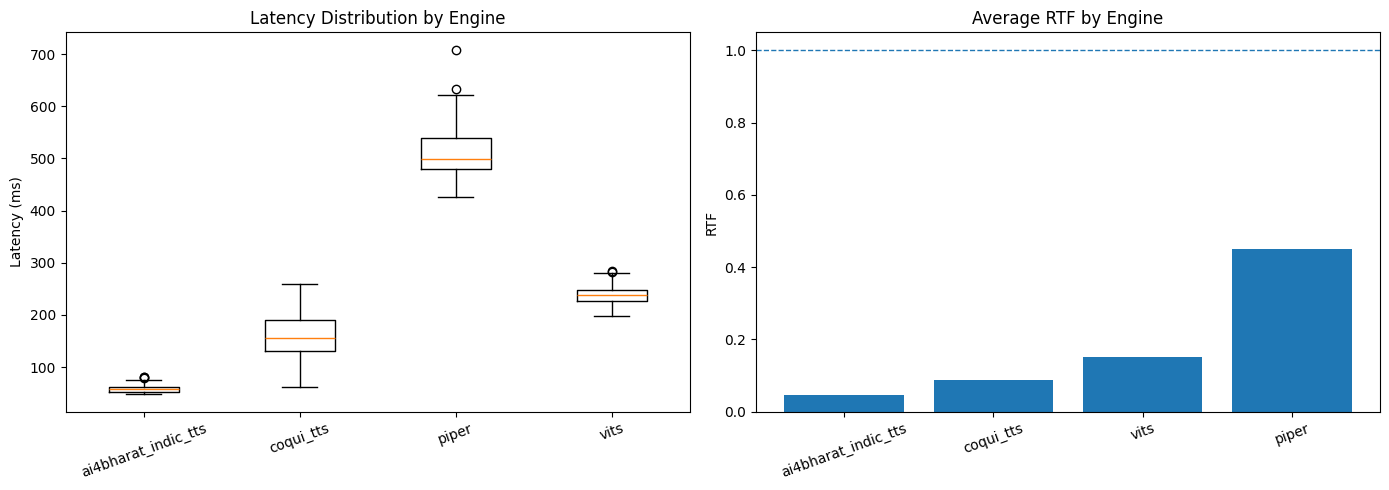

In [114]:
if not df_raw.empty:
    plot_df = df_raw[df_raw["status"] == "ok"].copy()
    plot_df["latency_ms"] = plot_df["synthesis_time_s"] * 1000.0

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    latency_box = [
        plot_df.loc[plot_df["engine"] == engine_name, "latency_ms"].dropna().values
        for engine_name in sorted(plot_df["engine"].unique())
    ]
    axes[0].boxplot(latency_box, labels=sorted(plot_df["engine"].unique()), vert=True)
    axes[0].set_title("Latency Distribution by Engine")
    axes[0].set_ylabel("Latency (ms)")
    axes[0].tick_params(axis="x", rotation=20)

    rtf_means = plot_df.groupby("engine", as_index=False)["rtf"].mean().sort_values("rtf")
    axes[1].bar(rtf_means["engine"], rtf_means["rtf"])
    axes[1].axhline(1.0, linestyle="--", linewidth=1)
    axes[1].set_title("Average RTF by Engine")
    axes[1].set_ylabel("RTF")
    axes[1].tick_params(axis="x", rotation=20)

    plt.tight_layout()
    plt.show()

## 6.1) Detailed Per-Command RTF Comparison

This section provides command-level latency/RTF tables and visual comparisons across engines.

Run-level command data (RTF + latency):


,run_id,engine,backend,language,category,text,run_idx,synthesis_time_s,audio_duration_s,rtf,latency_ms,status
0,tts_eval_20260316_213114,ai4bharat_indic_tts,hf_tts,en,nav,Door in front,1,0.059020,1.696000,0.034800,59.0201,ok
1,tts_eval_20260316_213114,ai4bharat_indic_tts,hf_tts,en,nav,Door in front,2,0.061768,1.616000,0.038223,61.7676,ok
2,tts_eval_20260316_213114,ai4bharat_indic_tts,hf_tts,en,nav,Door in front,3,0.062557,1.744000,0.035870,62.5573,ok
3,tts_eval_20260316_213114,ai4bharat_indic_tts,hf_tts,en,nav,Move left,1,0.064062,1.392000,0.046022,64.0620,ok
4,tts_eval_20260316_213114,ai4bharat_indic_tts,hf_tts,en,nav,Move left,2,0.073048,1.328000,0.055006,73.0476,ok
...,...,...,...,...,...,...,...,...,...,...,...,...
151,tts_eval_20260316_213114,vits,coqui_api,en,numeric,Stop after 5 meters,2,0.226978,2.218231,0.102324,226.9779,ok
152,tts_eval_20260316_213114,vits,coqui_api,en,numeric,Stop after 5 meters,3,0.237382,2.218231,0.107014,237.3821,ok
153,tts_eval_20260316_213114,vits,coqui_api,en,numeric,Turn right in 2 seconds,1,0.284174,2.671020,0.106391,284.1735,ok
154,tts_eval_20260316_213114,vits,coqui_api,en,numeric,Turn right in 2 seconds,2,0.243673,2.705850,0.090054,243.6734,ok


Command-level RTF summary by engine:


,engine,language,category,text,runs,avg_rtf,p95_rtf,min_rtf,max_rtf,avg_latency_ms,p95_latency_ms,avg_audio_duration_s
0,ai4bharat_indic_tts,en,nav,Door in front,3,0.036297,0.037987,0.034800,0.038223,61.115000,62.47833,1.685333
1,coqui_tts,en,nav,Door in front,3,0.093028,0.104569,0.085750,0.106545,151.435967,172.26868,1.626122
2,piper,en,nav,Door in front,3,0.551748,0.634830,0.426268,0.639916,545.312967,627.46716,0.989478
3,vits,en,nav,Door in front,3,0.178470,0.181121,0.174152,0.181244,250.882667,259.83555,1.405533
4,ai4bharat_indic_tts,en,nav,Move left,3,0.056962,0.068373,0.046022,0.069858,72.528833,79.73397,1.290667
5,coqui_tts,en,nav,Move left,3,0.092309,0.101215,0.084441,0.102458,137.175933,149.41574,1.486803
6,piper,en,nav,Move left,3,0.479252,0.489435,0.461060,0.489707,487.001167,497.40082,1.016568
7,vits,en,nav,Move left,3,0.182539,0.190717,0.173480,0.191630,229.510000,237.14707,1.258473
8,ai4bharat_indic_tts,en,nav,Move right,3,0.038449,0.039989,0.036711,0.040157,50.083467,53.03162,1.306667
9,coqui_tts,en,nav,Move right,3,0.088733,0.090003,0.087685,0.090189,127.107800,127.76094,1.432623


Saved command-level runs -> c:\workspace\IITM\vision-nav-assist\logs\tts_eval\tts_eval_20260316_213114_command_level_runs.csv
Saved command-level summary -> c:\workspace\IITM\vision-nav-assist\logs\tts_eval\tts_eval_20260316_213114_command_level_rtf_summary.csv


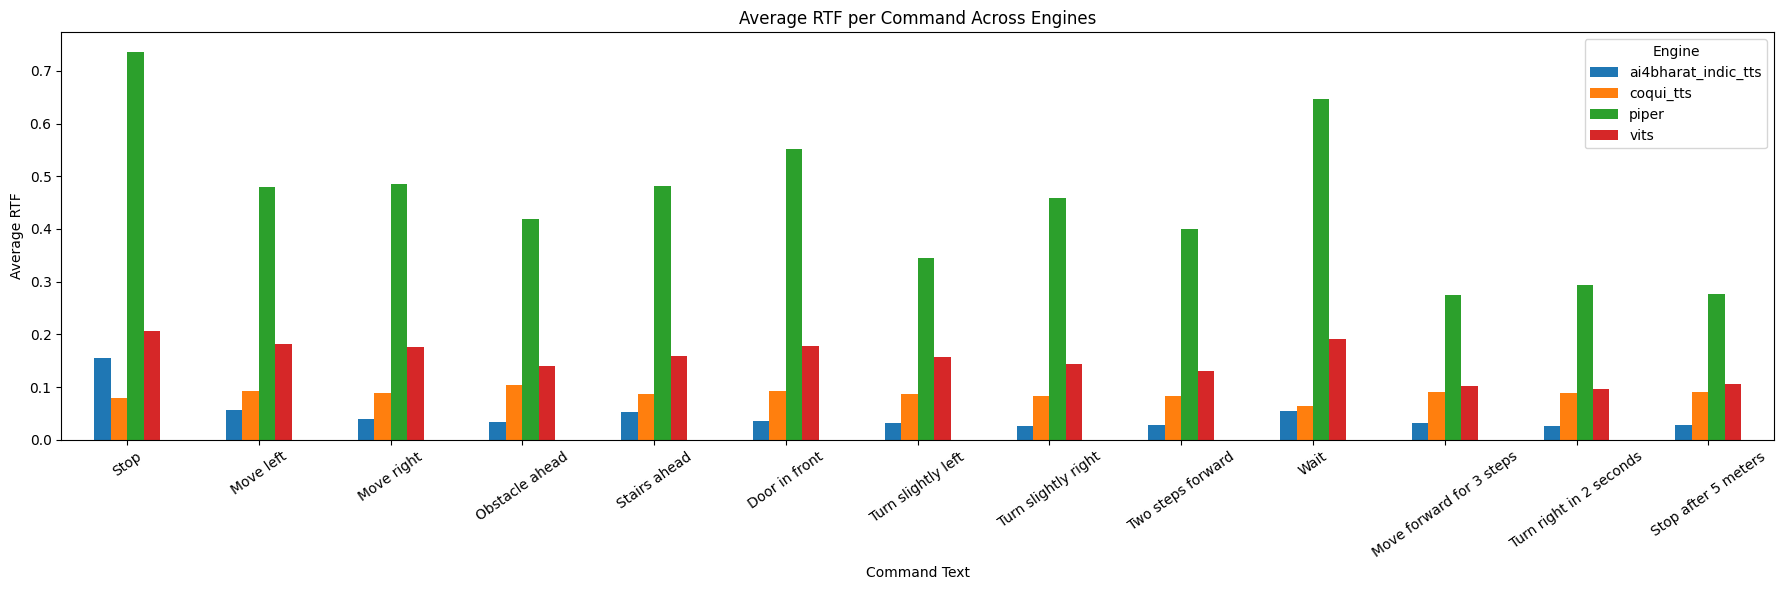

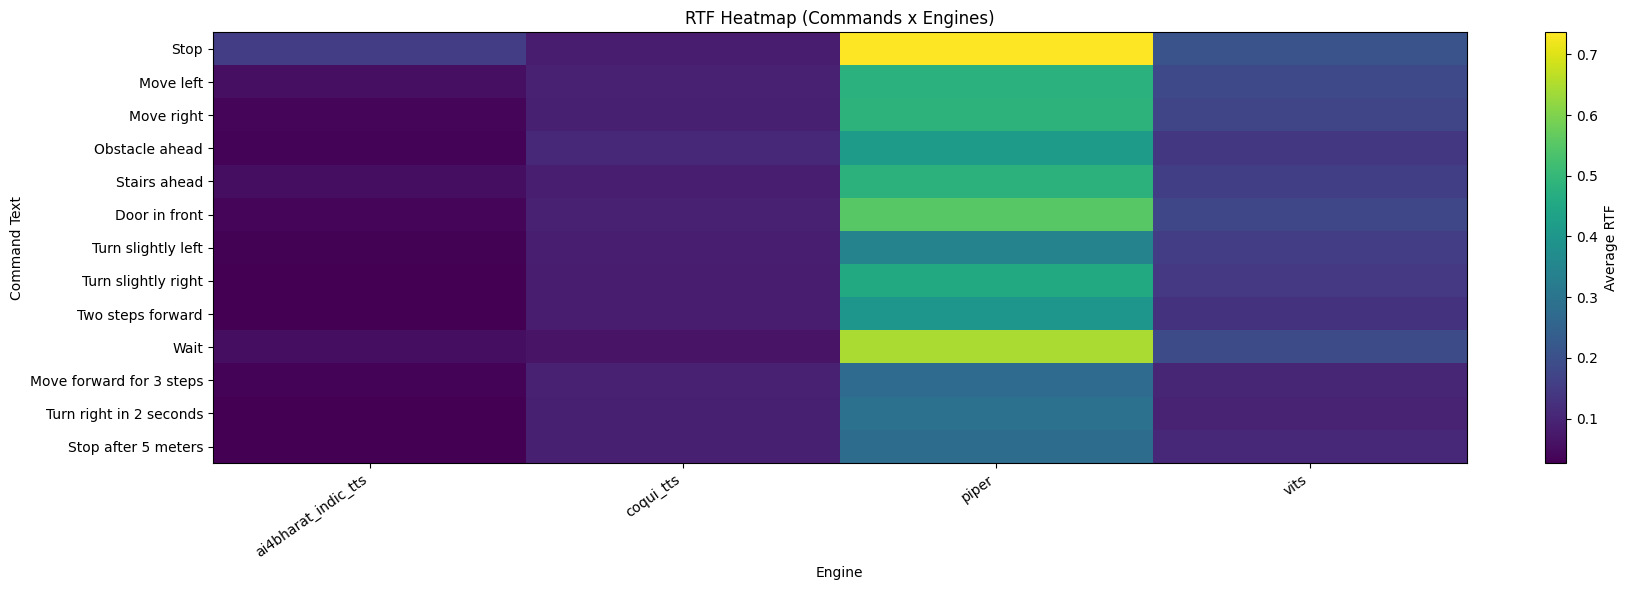

In [115]:
if df_raw.empty:
    print("Load benchmark data first.")
else:
    command_runs = df_raw[(df_raw["status"] == "ok") & (df_raw["text"].fillna("") != "")].copy()

    if command_runs.empty:
        print("No successful command-level rows available for RTF analysis.")
    else:
        command_runs["latency_ms"] = command_runs["synthesis_time_s"] * 1000.0

        command_detail_cols = [
            "run_id",
            "engine",
            "backend",
            "language",
            "category",
            "text",
            "run_idx",
            "synthesis_time_s",
            "audio_duration_s",
            "rtf",
            "latency_ms",
            "status",
        ]

        command_detail = (
            command_runs[command_detail_cols]
            .sort_values(["engine", "language", "category", "text", "run_idx"])
            .reset_index(drop=True)
        )

        command_summary = (
            command_runs.groupby(["engine", "language", "category", "text"], as_index=False)
            .agg(
                runs=("text", "count"),
                avg_rtf=("rtf", "mean"),
                p95_rtf=("rtf", lambda s: s.quantile(0.95)),
                min_rtf=("rtf", "min"),
                max_rtf=("rtf", "max"),
                avg_latency_ms=("latency_ms", "mean"),
                p95_latency_ms=("latency_ms", lambda s: s.quantile(0.95)),
                avg_audio_duration_s=("audio_duration_s", "mean"),
            )
            .sort_values(["language", "category", "text", "engine"])
            .reset_index(drop=True)
        )

        print("Run-level command data (RTF + latency):")
        display(command_detail)

        print("Command-level RTF summary by engine:")
        display(command_summary)

        run_label = (
            command_runs["run_id"].dropna().astype(str).iloc[0]
            if "run_id" in command_runs.columns and not command_runs["run_id"].dropna().empty
            else RUN_ID
        )

        detail_out = TTS_LOG_DIR / f"{run_label}_command_level_runs.csv"
        summary_out = TTS_LOG_DIR / f"{run_label}_command_level_rtf_summary.csv"

        command_detail.to_csv(detail_out, index=False, encoding="utf-8")
        command_summary.to_csv(summary_out, index=False, encoding="utf-8")

        print(f"Saved command-level runs -> {detail_out}")
        print(f"Saved command-level summary -> {summary_out}")

        pivot = command_summary.pivot_table(index="text", columns="engine", values="avg_rtf", aggfunc="mean")

        if "TEST_ITEMS_TO_RUN" in globals() and TEST_ITEMS_TO_RUN:
            command_order = []
            seen = set()
            for item in TEST_ITEMS_TO_RUN:
                text_value = item.get("text", "")
                if text_value and text_value in pivot.index and text_value not in seen:
                    command_order.append(text_value)
                    seen.add(text_value)
            if command_order:
                pivot = pivot.reindex(command_order)

        if pivot.empty:
            print("Not enough data to plot per-command RTF charts.")
        else:
            ax = pivot.plot(kind="bar", figsize=(18, 6))
            ax.set_title("Average RTF per Command Across Engines")
            ax.set_ylabel("Average RTF")
            ax.set_xlabel("Command Text")
            ax.tick_params(axis="x", rotation=35)
            ax.legend(title="Engine")
            plt.tight_layout()
            plt.show()

            heatmap_values = pivot.to_numpy(dtype=float)
            fig, ax = plt.subplots(figsize=(18, 6))
            image = ax.imshow(heatmap_values, aspect="auto")
            ax.set_title("RTF Heatmap (Commands x Engines)")
            ax.set_xlabel("Engine")
            ax.set_ylabel("Command Text")
            ax.set_xticks(range(len(pivot.columns)))
            ax.set_xticklabels(list(pivot.columns), rotation=35, ha="right")
            ax.set_yticks(range(len(pivot.index)))
            ax.set_yticklabels(list(pivot.index))
            fig.colorbar(image, ax=ax, label="Average RTF")
            plt.tight_layout()
            plt.show()

## 7) Intelligibility Evaluation (Human annotae)

This captures the **one-listen understanding rate** from the plan.
- `understood_first_try`: 1 for correct on first hearing, else 0
- One row per `(engine, language, text, listener_id)`

In [116]:
if df_raw.empty:
    print("Load benchmark data first.")
    intelligibility_rates = pd.DataFrame()
else:
    ann_path = TTS_LOG_DIR / "intelligibility_annotations.csv"

    if not ann_path.exists():
        base = (
            df_raw[df_raw["status"] == "ok"][["engine", "language", "text", "audio_path"]]
            .drop_duplicates()
            .reset_index(drop=True)
        )
        base["listener_id"] = ""
        base["understood_first_try"] = ""
        base["transcribed_text"] = ""
        base["notes"] = ""
        base.to_csv(ann_path, index=False, encoding="utf-8")
        print(f"Created annotation template -> {ann_path}")
        print("Fill it and rerun this cell.")
        intelligibility_rates = pd.DataFrame()
    else:
        ann_df = pd.read_csv(ann_path)
        ann_df["understood_first_try"] = pd.to_numeric(
            ann_df["understood_first_try"], errors="coerce"
        )
        rated = ann_df.dropna(subset=["understood_first_try"]).copy()

        if rated.empty:
            print(f"Annotation file exists but no rated rows yet: {ann_path}")
            intelligibility_rates = pd.DataFrame()
        else:
            intelligibility_rates = (
                rated.groupby(["engine", "language"], as_index=False)
                .agg(
                    intelligibility_rate=("understood_first_try", "mean"),
                    samples=("understood_first_try", "count"),
                )
                .sort_values(["engine", "language"])
            )
            display(intelligibility_rates)

            out_intel = TTS_LOG_DIR / f"{RUN_ID}_intelligibility_summary.csv"
            intelligibility_rates.to_csv(out_intel, index=False, encoding="utf-8")
            print(f"Saved intelligibility summary -> {out_intel}")

Annotation file exists but no rated rows yet: c:\workspace\IITM\vision-nav-assist\logs\tts_eval\intelligibility_annotations.csv


## 8) Pronunciation Quality (Qualitative Rating)

Use 1–5 scale (`5 = excellent pronunciation`) per row in `pronunciation_ratings.csv`.

In [117]:
if df_raw.empty:
    print("Load benchmark data first.")
    pronunciation_summary = pd.DataFrame()
else:
    pron_path = TTS_LOG_DIR / "pronunciation_ratings.csv"

    if not pron_path.exists():
        base = (
            df_raw[df_raw["status"] == "ok"][["engine", "language", "text", "audio_path"]]
            .drop_duplicates()
            .reset_index(drop=True)
        )
        base["rater_id"] = ""
        base["pronunciation_score_1_5"] = ""
        base["notes"] = ""
        base.to_csv(pron_path, index=False, encoding="utf-8")
        print(f"Created pronunciation template -> {pron_path}")
        print("Fill it and rerun this cell.")
        pronunciation_summary = pd.DataFrame()
    else:
        pron_df = pd.read_csv(pron_path)
        pron_df["pronunciation_score_1_5"] = pd.to_numeric(
            pron_df["pronunciation_score_1_5"], errors="coerce"
        )
        rated = pron_df.dropna(subset=["pronunciation_score_1_5"]).copy()

        if rated.empty:
            print(f"Rating file exists but no scored rows yet: {pron_path}")
            pronunciation_summary = pd.DataFrame()
        else:
            pronunciation_summary = (
                rated.groupby(["engine", "language"], as_index=False)
                .agg(
                    pronunciation_score=("pronunciation_score_1_5", "mean"),
                    samples=("pronunciation_score_1_5", "count"),
                )
                .sort_values(["engine", "language"])
            )
            display(pronunciation_summary)

            out_pron = TTS_LOG_DIR / f"{RUN_ID}_pronunciation_summary.csv"
            pronunciation_summary.to_csv(out_pron, index=False, encoding="utf-8")
            print(f"Saved pronunciation summary -> {out_pron}")

Rating file exists but no scored rows yet: c:\workspace\IITM\vision-nav-assist\logs\tts_eval\pronunciation_ratings.csv


## 9) Final Model Ranking (Latency + Intelligibility + Pronunciation)

Weighted score (editable):
- Lower is better: average latency, P95 latency, RTF
- Higher is better: intelligibility rate, pronunciation score

In [118]:
def minmax(series: pd.Series, reverse: bool = False) -> pd.Series:
    s = series.astype(float)
    if s.nunique(dropna=True) <= 1:
        out = pd.Series([0.5] * len(s), index=s.index)
    else:
        out = (s - s.min()) / (s.max() - s.min())
    return 1.0 - out if reverse else out


if metrics_overall.empty:
    print("Run metrics section first.")
else:
    rank_df = metrics_overall.copy()

    if not intelligibility_rates.empty:
        intel_overall = intelligibility_rates.groupby("engine", as_index=False)["intelligibility_rate"].mean()
        rank_df = rank_df.merge(intel_overall, on="engine", how="left")
    else:
        rank_df["intelligibility_rate"] = pd.NA

    if not pronunciation_summary.empty:
        pron_overall = pronunciation_summary.groupby("engine", as_index=False)["pronunciation_score"].mean()
        rank_df = rank_df.merge(pron_overall, on="engine", how="left")
    else:
        rank_df["pronunciation_score"] = pd.NA

    rank_df["latency_score"] = minmax(rank_df["avg_latency_ms"], reverse=True)
    rank_df["p95_score"] = minmax(rank_df["p95_latency_ms"], reverse=True)
    rank_df["rtf_score"] = minmax(rank_df["avg_rtf"], reverse=True)
    rank_df["intel_score"] = minmax(rank_df["intelligibility_rate"].fillna(rank_df["intelligibility_rate"].mean()), reverse=False)
    rank_df["pron_score"] = minmax(rank_df["pronunciation_score"].fillna(rank_df["pronunciation_score"].mean()), reverse=False)

    WEIGHTS = {
        "latency_score": 0.30,
        "p95_score": 0.25,
        "rtf_score": 0.15,
        "intel_score": 0.20,
        "pron_score": 0.10,
    }

    rank_df["final_score"] = sum(rank_df[k] * w for k, w in WEIGHTS.items())
    rank_df = rank_df.sort_values("final_score", ascending=False).reset_index(drop=True)

    display(rank_df[[
        "engine",
        "avg_latency_ms",
        "p95_latency_ms",
        "avg_rtf",
        "intelligibility_rate",
        "pronunciation_score",
        "final_score",
    ]])

    rank_out = TTS_LOG_DIR / f"{RUN_ID}_final_ranking.csv"
    rank_df.to_csv(rank_out, index=False, encoding="utf-8")
    print(f"Saved final ranking -> {rank_out}")

,engine,avg_latency_ms,p95_latency_ms,avg_rtf,intelligibility_rate,pronunciation_score,final_score
0,ai4bharat_indic_tts,59.479651,78.62110,0.046082,<NA>,<NA>,0.850000
1,coqui_tts,160.052677,244.36841,0.087017,<NA>,<NA>,0.692738
2,vits,239.921033,281.24428,0.151517,<NA>,<NA>,0.599433
3,piper,516.607541,623.51080,0.449708,<NA>,<NA>,0.150000


Saved final ranking -> c:\workspace\IITM\vision-nav-assist\logs\tts_eval\tts_eval_20260316_213114_final_ranking.csv


## 9.1) Final RTF Comparison (All 4 TTS Engines)

This chart compares RTF across all enabled TTS engines using average and P95 RTF from the latest successful runs.

RTF comparison table (all engines):


,engine,runs,avg_rtf,p95_rtf,avg_latency_ms
0,ai4bharat_indic_tts,39,0.046082,0.113526,59.479651
1,coqui_tts,39,0.087017,0.102866,160.052677
2,vits,39,0.151517,0.200779,239.921033
3,piper,39,0.449708,0.724297,516.607541


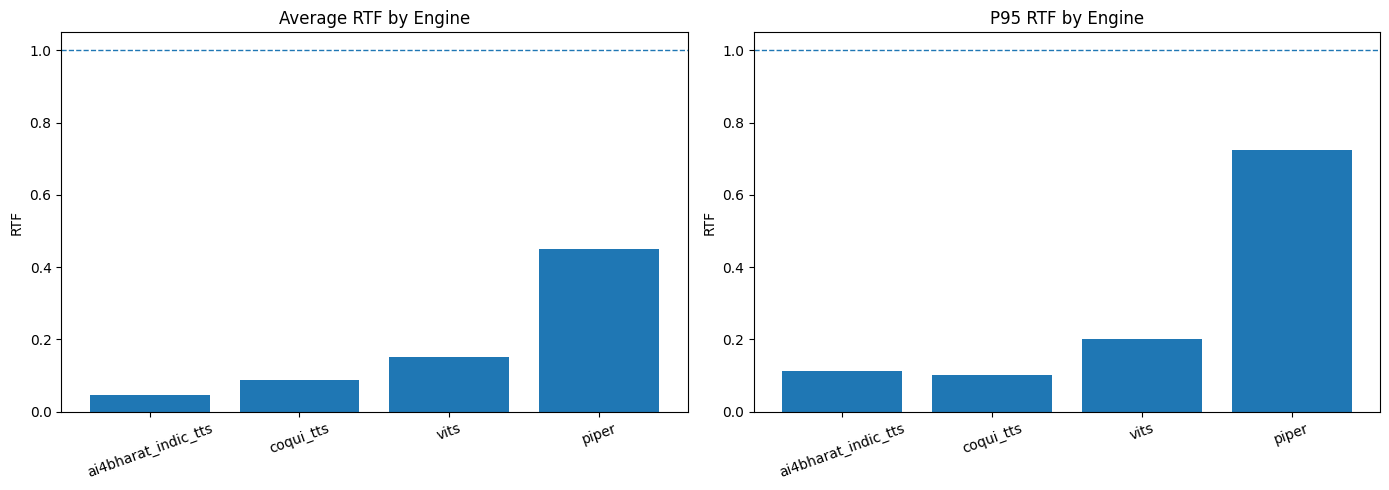

In [119]:
if df_raw.empty:
    print("Run benchmark first to compare RTF across engines.")
else:
    rtf_source = df_raw[df_raw["status"] == "ok"].copy()

    if rtf_source.empty:
        print("No successful rows available for RTF comparison.")
    else:
        rtf_compare = (
            rtf_source.groupby("engine", as_index=False)
            .agg(
                runs=("text", "count"),
                avg_rtf=("rtf", "mean"),
                p95_rtf=("rtf", lambda s: s.quantile(0.95)),
                avg_latency_ms=("synthesis_time_s", lambda s: s.mean() * 1000.0),
            )
            .sort_values("avg_rtf")
            .reset_index(drop=True)
        )

        print("RTF comparison table (all engines):")
        display(rtf_compare)

        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        axes[0].bar(rtf_compare["engine"], rtf_compare["avg_rtf"])
        axes[0].axhline(1.0, linestyle="--", linewidth=1)
        axes[0].set_title("Average RTF by Engine")
        axes[0].set_ylabel("RTF")
        axes[0].tick_params(axis="x", rotation=20)

        axes[1].bar(rtf_compare["engine"], rtf_compare["p95_rtf"])
        axes[1].axhline(1.0, linestyle="--", linewidth=1)
        axes[1].set_title("P95 RTF by Engine")
        axes[1].set_ylabel("RTF")
        axes[1].tick_params(axis="x", rotation=20)

        plt.tight_layout()
        plt.show()

## 10) Integration Checklist

After selecting the winning TTS model:
1. Integrate the engine into the pipeline stage `Command Generation -> Text-to-Speech -> Audio Output`
2. Record real-time end-to-end latency impact in `logs/telemetry`
3. Re-run this notebook for CPU-only and GPU-assisted settings
4. Finalize multilingual scope with the team (Tamil/Gujarati availability)

## 11) Custom Dataset + Public Dataset (Pipeline + TTS)

Adds TTS RTF measurements for (1) the latest custom-video run and (2) public dataset benchmark results.

In [ ]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

OUTPUTS_DIR = ROOT / 'outputs'
RESULTS_DIR = ROOT / 'results'

def latest_run(prefix: str) -> Path | None:
    if not OUTPUTS_DIR.exists():
        return None
    candidates = [p for p in OUTPUTS_DIR.iterdir() if p.is_dir() and p.name.startswith(prefix)]
    if not candidates:
        return None
    candidates.sort(key=lambda p: p.stat().st_mtime)
    return candidates[-1]

CUSTOM_RUN_DIR = latest_run('dataset_eval_')
BENCH_RUN_DIR = latest_run('benchmark_')

print('Latest custom run:', CUSTOM_RUN_DIR)
print('Latest benchmark run:', BENCH_RUN_DIR)


### 11.1 Custom Dataset (Video) - Pipeline + TTS Gate Stats

In [ ]:
if not CUSTOM_RUN_DIR:
    print('No dataset_eval_* run found in outputs/. Run the custom video runner config first.')
else:
    frame_csv = CUSTOM_RUN_DIR / 'frame_metrics.csv'
    lat_csv = CUSTOM_RUN_DIR / 'latency_summary.csv'

    df = pd.read_csv(frame_csv)
    lat = pd.read_csv(lat_csv).iloc[0]

    print('Frames:', len(df))
    display(pd.DataFrame([lat]))

    # Navigation command distribution
    if 'nav_command' in df.columns:
        cmd_counts = df['nav_command'].fillna('None').astype(str).value_counts().head(12)
        display(cmd_counts.to_frame('count'))

    # TTS gate stats
    out = {}
    if 'tts_should_speak' in df.columns:
        out['tts_should_speak_rate'] = df['tts_should_speak'].fillna(False).astype(bool).mean()
        out['tts_should_speak_count'] = int(df['tts_should_speak'].fillna(False).astype(bool).sum())
    if 'tts_skip_reason' in df.columns:
        display(df['tts_skip_reason'].fillna('None').astype(str).value_counts().to_frame('count'))
    if 'tts_enqueue_ok' in df.columns:
        out['tts_enqueue_fail_count'] = int((~df['tts_enqueue_ok'].fillna(True).astype(bool)).sum())

    display(pd.DataFrame([out]))


### 11.2 Public Dataset (EgoBlind) — Benchmark Table (Existing Runs)

In [ ]:
if not BENCH_RUN_DIR:
    print('No benchmark_* run found in outputs/.')
else:
    cmp = BENCH_RUN_DIR / 'benchmark_comparison.csv'
    if not cmp.exists():
        print('No benchmark_comparison.csv in', BENCH_RUN_DIR)
    else:
        bdf = pd.read_csv(cmp)
        display(bdf.sort_values('avg_fps', ascending=False))


### 11.3 Piper RTF On Custom Commands (Derived From Custom Run)

In [ ]:
import sys
import time
import wave
from datetime import date

sys.path.insert(0, str(ROOT))
from app.mechanics.nav_tts_piper import PiperTTS
from app.utils.paths import env_rel_path

def wav_duration_s(path: Path) -> float:
    with wave.open(str(path), 'rb') as f:
        return f.getnframes() / float(f.getframerate())

piper_exe = env_rel_path('PIPER_EXE_REL', str(Path('piper') / 'piper.exe'))
voice_model = env_rel_path('PIPER_VOICE_MODEL_REL', str(Path('app') / 'piper_voices' / 'en_US-amy-medium.onnx'))
voice_cfg = env_rel_path('PIPER_VOICE_CONFIG_REL', str(Path('app') / 'piper_voices' / 'en_US-amy-medium.onnx.json'))

out_dir = RESULTS_DIR / f"tts_custom_rtf_{date.today().isoformat()}"
wav_dir = out_dir / 'wav'
wav_dir.mkdir(parents=True, exist_ok=True)

tts = PiperTTS(
    piper_executable=str(piper_exe),
    voice_model_path=str(voice_model),
    voice_config_path=str(voice_cfg),
    output_dir=str(wav_dir),
)

if CUSTOM_RUN_DIR and (CUSTOM_RUN_DIR / 'frame_metrics.csv').exists():
    tmp = pd.read_csv(CUSTOM_RUN_DIR / 'frame_metrics.csv')
    cmds = (
        tmp['nav_command']
        .fillna('')
        .astype(str)
        .map(str.strip)
    )
    cmds = [c for c in cmds.unique().tolist() if c]
    # Keep it compact for the report.
    commands = cmds[:12]
else:
    commands = [
        'Path clear. Continue straight.',
        'Clear path on your left. Turn left.',
        'Clear path on your right. Turn right.',
        'Obstacle ahead. Move slightly left.',
        'Obstacle ahead. Move slightly right.',
        'Path blocked. Please scan left and right.',
    ]

rows = []
for i, text in enumerate(commands, start=1):
    wav_path = wav_dir / f'cmd_{i:02d}.wav'
    t0 = time.perf_counter()
    tts.synthesize(text, output_wav_path=str(wav_path), play_audio=False)
    synth_s = time.perf_counter() - t0
    dur_s = wav_duration_s(wav_path)
    rtf = (synth_s / dur_s) if dur_s else None
    rows.append({'idx': i, 'text': text, 'wav': str(wav_path), 'synth_s': synth_s, 'dur_s': dur_s, 'rtf': rtf})

rtf_df = pd.DataFrame(rows)
display(rtf_df)

fig, ax = plt.subplots(figsize=(10, 3))
ax.bar(rtf_df['idx'], rtf_df['rtf'])
ax.set_xlabel('Command idx')
ax.set_ylabel('RTF (synth_time / audio_time)')
ax.set_title('Piper RTF on Custom Dataset Commands')
plt.tight_layout()
plt.show()
